# Pharmacy Sales — XGBoost Forecasting Model

**Data Pipeline:**
1. ✅ `data_cleaning.ipynb` - Cleaned data (outliers handled, 100% quality)
2. ✅ `pharmacy_sales_feature_engineering.ipynb` - Created 50+ features
3. ✅ `pharmacy_sales_baseline_models.ipynb` - Holt-Winters benchmark
4. ✅ `pharmacy_sarima_model.ipynb` - SARIMA statistical models
5. 📍 **This notebook** - XGBoost machine learning model (Train + 2018 Validation)
6. ⏭ `model_validation_2019.ipynb` - Final out-of-sample test on 2019 data

**Temporal Split Strategy (3-way — no data leakage):**
| Split | Years | Purpose |
|-------|-------|---------|
| **Training** | 2014–2017 | Learn historical demand patterns |
| **Validation** | 2018 (full year) | Tune hyperparameters, compare models |
| **Final Test** | 2019 | Unseen out-of-sample evaluation |

**Machine learning approach with 50+ engineered features**

**Benchmarks to beat (evaluated on same 2018 validation set):**
- **Holt-Winters**: MAE 6.91 | WMAPE 28.36% | R²: -0.39
- **SARIMA (avg)**: MAE 8.73 | WMAPE 31.89% | R²: -1.03
- **Best SARIMA**: N02BE MAE 0.00 (perfect fit on stable drug)

**XGBoost advantages:**
- Can learn complex non-linear patterns
- Handles multiple drugs in one model (learns cross-drug patterns)
- Uses all engineered features (lags, rolling stats, trends, seasonality)
- No stationarity requirements
- Should excel on seasonal drugs (R03, R06) where SARIMA struggled

**Success Criteria:** XGBoost must achieve overall MAE < 6.91 on 2018 validation set


In [2]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f'✓ Project root: {project_root}')

✓ Project root: /home/brenda/final year project/PharmacyForecastingSystem


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
print('✓ XGBoost', xgb.__version__)

✓ XGBoost 2.0.3


## 1. LOAD PREPARED DATA WITH FEATURES

**Data Source:** Feature-engineered data from `pharmacy_sales_feature_engineering.ipynb`
- 50+ features including lags, rolling stats, trends, seasonality
- Same train/test temporal split as baseline and SARIMA models
- Features automatically extracted from dataframe

In [4]:
from pathlib import Path

data_dir = Path(project_root) / 'data' / 'processed'

print("Loading feature-engineered data...")
print(f"Source: {data_dir}")

# Load data with all engineered features
train_df = pd.read_csv(data_dir / 'train_xgboost.csv', parse_dates=['week_start_date'])
test_df  = pd.read_csv(data_dir / 'test_xgboost.csv', parse_dates=['week_start_date'])

# Get unique drugs from the data
selected_drugs = sorted(train_df['drug_name'].unique().tolist())

# Define target and metadata columns to exclude from features
TARGET = 'total_quantity'
metadata_cols = ['year', 'week_number', 'week_start_date', 'week_end_date', 
                 'drug_name', 'atc_code', 'atc_main_group', 'drug_id', TARGET, 
                 'avg_daily_quantity', 'is_complete_year', 'total_quantity_scaled']

# Automatically detect feature columns (only numeric columns, excluding metadata)
# This ensures XGBoost only gets numeric data (int, float)
numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in metadata_cols]

print('\n' + '=' * 60)
print('DATA LOADED FROM FEATURE ENGINEERING')
print('=' * 60)
print(f'Train : {len(train_df):,} rows  ({train_df.week_start_date.min().date()} to {train_df.week_start_date.max().date()})')
print(f'Test  : {len(test_df):,} rows  ({test_df.week_start_date.min().date()} to {test_df.week_start_date.max().date()})')
print(f'Features: {len(feature_cols)} (numeric only)')
print(f'Drugs : {len(selected_drugs)}')
print(f'Selected drugs: {", ".join(selected_drugs)}')

# Verify no object dtypes in features
print(f'\n✓ Feature data types verified:')
print(f'  All features are numeric: {train_df[feature_cols].select_dtypes(include=[np.number]).shape[1] == len(feature_cols)}')

# Load drug segments from SARIMA results if available
try:
    with open(Path(project_root) / 'results' / 'sarima' / 'drug_segments.pkl', 'rb') as f:
        seg_map = pickle.load(f)
    print('\n✓ Loaded drug segments from SARIMA results')
except:
    # Create generic segments based on mean sales
    seg_map = {}
    for drug in selected_drugs:
        mean_qty = train_df[train_df['drug_name'] == drug][TARGET].mean()
        if mean_qty < 10:
            seg_map[drug] = 'Low Volume'
        elif mean_qty >= 50:
            seg_map[drug] = 'High Volume'
        else:
            seg_map[drug] = 'Medium Volume'
    print('\n✓ Created drug segments from training data')

# Benchmarks to beat
BASELINE_MAE   = 6.91
BASELINE_WMAPE = 28.36
SARIMA_AVG_MAE = 8.73
SARIMA_AVG_WMAPE = 31.89

print(f'\n{"=" * 60}')
print('BENCHMARKS TO BEAT')
print('=' * 60)
print(f'Holt-Winters : MAE {BASELINE_MAE} | WMAPE {BASELINE_WMAPE}%')
print(f'SARIMA (avg) : MAE {SARIMA_AVG_MAE} | WMAPE {SARIMA_AVG_WMAPE}%')
print(f'\n✓ Using same data pipeline as baseline/SARIMA for fair comparison')

Loading feature-engineered data...
Source: /home/brenda/final year project/PharmacyForecastingSystem/data/processed

DATA LOADED FROM FEATURE ENGINEERING
Train : 1,230 rows  (2014-12-29 to 2017-12-25)
Test  : 407 rows  (2018-01-01 to 2018-12-24)
Features: 47 (numeric only)
Drugs : 8
Selected drugs: M01AB, M01AE, N02BA, N02BE, N05B, N05C, R03, R06

✓ Feature data types verified:
  All features are numeric: True

✓ Created drug segments from training data

BENCHMARKS TO BEAT
Holt-Winters : MAE 6.91 | WMAPE 28.36%
SARIMA (avg) : MAE 8.73 | WMAPE 31.89%

✓ Using same data pipeline as baseline/SARIMA for fair comparison


In [17]:

# ── DATA LEAKAGE SANITY CHECK ──────────────────────────────────────────────
print('=== DATE SPLIT VALIDATION ===')
print(f'Train : {train_df["week_start_date"].min().date()}  →  {train_df["week_start_date"].max().date()}')
print(f'Test  : {test_df["week_start_date"].min().date()}  →  {test_df["week_start_date"].max().date()}')

gap = (test_df['week_start_date'].min() - train_df['week_start_date'].max()).days
overlap = train_df['week_start_date'].isin(test_df['week_start_date']).sum()

print(f'\nGap between train end and test start : {gap} days')
print(f'Overlapping dates                    : {overlap}')

if overlap == 0 and gap >= 0:
    print('\n✅ No data leakage — clean temporal split')
else:
    print('\n❌ WARNING: Data leakage detected! Train and test dates overlap.')

# Check lag features don't use future data
print('\n=== FEATURE COLUMNS ===')
lag_cols = [c for c in train_df.columns if 'lag' in c.lower() or 'roll' in c.lower()]
print(f'Lag/rolling features: {lag_cols if lag_cols else "None found in train_df (likely added during modeling)"}')
print(f'All columns: {list(train_df.columns)}')


=== DATE SPLIT VALIDATION ===
Train : 2014-12-29  →  2017-12-25
Test  : 2018-01-01  →  2018-12-24

Gap between train end and test start : 7 days
Overlapping dates                    : 0

✅ No data leakage — clean temporal split

=== FEATURE COLUMNS ===
Lag/rolling features: ['total_quantity_lag_1', 'total_quantity_lag_2', 'total_quantity_lag_4', 'total_quantity_lag_13', 'total_quantity_lag_52', 'total_quantity_rolling_mean_4', 'total_quantity_rolling_std_4', 'total_quantity_rolling_min_4', 'total_quantity_rolling_max_4', 'total_quantity_rolling_mean_13', 'total_quantity_rolling_std_13', 'total_quantity_rolling_min_13', 'total_quantity_rolling_max_13', 'total_quantity_rolling_mean_26', 'total_quantity_rolling_std_26', 'total_quantity_rolling_min_26', 'total_quantity_rolling_max_26', 'total_quantity_rolling_mean_52', 'total_quantity_rolling_std_52', 'total_quantity_rolling_min_52', 'total_quantity_rolling_max_52']
All columns: ['year', 'week_number', 'week_start_date', 'week_end_date', '

## 2. EVALUATION METRICS

In [5]:
def calculate_metrics(y_true, y_pred, model_name='XGBoost', drug=None, segment=None):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.clip(np.array(y_pred, dtype=float), 0, None)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    mask = y_true > 5
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan

    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100 if np.sum(y_true) > 0 else np.nan

    return {
        'Model'  : model_name,
        'Drug'   : drug,
        'Segment': segment,
        'MAE'    : round(mae,  2),
        'RMSE'   : round(rmse, 2),
        'MAPE'   : round(mape, 2) if not np.isnan(mape) else None,
        'WMAPE'  : round(wmape, 2) if not np.isnan(wmape) else None,
        'R2'     : round(r2,   4)
    }

print('✓ Metrics helper defined (WMAPE primary)')

✓ Metrics helper defined (WMAPE primary)


## 3. PREPARE TRAINING DATA

In [6]:
# Separate features and target
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET].copy()
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET].copy()

# Store metadata for later
train_meta = train_df[['drug_name','week_start_date']].copy()
test_meta  = test_df[['drug_name','week_start_date']].copy()

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'\nMissing in X_train: {X_train.isnull().sum().sum()}')
print(f'Missing in X_test : {X_test.isnull().sum().sum()}')

# Fill any remaining missing values
if X_train.isnull().sum().sum() > 0 or X_test.isnull().sum().sum() > 0:
    print('\nFilling remaining missing values with 0...')
    X_train = X_train.fillna(0)
    X_test  = X_test.fillna(0)
    print('✓ Done')

X_train: (1230, 47)
X_test : (407, 47)

Missing in X_train: 0
Missing in X_test : 0


## 4. HYPERPARAMETER TUNING WITH TIME SERIES CV

In [7]:
# Define param grid — these are good starting points for time series
param_grid = {
    'max_depth':       [3, 5, 7],
    'learning_rate':   [0.01, 0.05, 0.1],
    'n_estimators':    [100, 200, 300],
    'subsample':       [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Time series cross-validation (no shuffle!)
tscv = TimeSeriesSplit(n_splits=3)

print('=== HYPERPARAMETER TUNING ===')
print(f'Param grid combinations: {3*3*3*2*2} = 108')
print('Using TimeSeriesSplit with 3 folds')
print('This may take 5-10 minutes...\n')

best_mae   = np.inf
best_params = None

# Grid search
for max_depth in param_grid['max_depth']:
    for lr in param_grid['learning_rate']:
        for n_est in param_grid['n_estimators']:
            for ss in param_grid['subsample']:
                for csbt in param_grid['colsample_bytree']:
                    
                    params = {
                        'max_depth': max_depth,
                        'learning_rate': lr,
                        'n_estimators': n_est,
                        'subsample': ss,
                        'colsample_bytree': csbt,
                        'objective': 'reg:squarederror',
                        'random_state': 42,
                        'n_jobs': -1
                    }
                    
                    fold_maes = []
                    for train_idx, val_idx in tscv.split(X_train):
                        X_t, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
                        y_t, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
                        
                        model = xgb.XGBRegressor(**params)
                        model.fit(X_t, y_t, verbose=False)
                        pred = model.predict(X_v)
                        mae  = mean_absolute_error(y_v, pred)
                        fold_maes.append(mae)
                    
                    avg_mae = np.mean(fold_maes)
                    
                    if avg_mae < best_mae:
                        best_mae    = avg_mae
                        best_params = params
                        print(f'✓ New best  MAE={avg_mae:.2f}  {params}')

print(f'\n=== BEST PARAMETERS ===')
print(f'MAE on CV: {best_mae:.2f}')
for k, v in best_params.items():
    print(f'  {k:20s}: {v}')

=== HYPERPARAMETER TUNING ===
Param grid combinations: 108 = 108
Using TimeSeriesSplit with 3 folds
This may take 5-10 minutes...

✓ New best  MAE=22.38  {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 100, 'subsample': 0.8, 'colsample_bytree': 0.8, 'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1}
✓ New best  MAE=20.18  {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 200, 'subsample': 0.8, 'colsample_bytree': 0.8, 'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1}
✓ New best  MAE=19.07  {'max_depth': 3, 'learning_rate': 0.01, 'n_estimators': 300, 'subsample': 0.8, 'colsample_bytree': 0.8, 'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1}
✓ New best  MAE=17.94  {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 100, 'subsample': 0.8, 'colsample_bytree': 0.8, 'objective': 'reg:squarederror', 'random_state': 42, 'n_jobs': -1}
✓ New best  MAE=17.48  {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 200, 'subsampl

## 5. TRAIN FINAL MODEL ON FULL TRAINING SET

In [8]:
print('=== TRAINING FINAL MODEL ===')
print('Training period  : 2014-2017')
print('Validation period: 2018 (full year)')
final_model = xgb.XGBRegressor(**best_params)
final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Predict on 2018 validation set
y_pred = final_model.predict(X_test)
y_pred = np.clip(y_pred, 0, None)   # no negative sales

print('✓ Model trained on 2014-2017 data')
print(f'  Training samples  : {len(X_train):,}')
print(f'  Validation samples: {len(X_test):,}  (2018 full year)')
print(f'\nNext step: Run model_validation_2019.ipynb for final 2019 test')


=== TRAINING FINAL MODEL ===
Training period  : 2014-2017
Validation period: 2018 (full year)
✓ Model trained on 2014-2017 data
  Training samples  : 1,230
  Validation samples: 407  (2018 full year)

Next step: Run model_validation_2019.ipynb for final 2019 test


## 6. OVERALL PERFORMANCE

In [9]:
overall_metrics = calculate_metrics(y_test, y_pred, model_name='XGBoost (2018 Validation)')

print('=== XGBOOST 2018 VALIDATION PERFORMANCE ===')
print('(Model trained on 2014-2017, evaluated on full year 2018)')
for k, v in overall_metrics.items():
    if k not in ['Drug','Segment']:
        print(f'{k:8s}: {v}')

print('\n=== COMPARISON vs BASELINES (same 2018 validation set) ===')
comparison = pd.DataFrame({
    'Holt-Winters': [BASELINE_MAE,   '—', 28.36, -0.39],
    'SARIMA (avg)': [SARIMA_AVG_MAE, '—', 31.89, -1.03],
    'XGBoost'     : [overall_metrics['MAE'], overall_metrics['WMAPE'],
                     overall_metrics['MAPE'], overall_metrics['R2']]
}, index=['MAE','WMAPE','MAPE','R2'])
display(comparison)

if overall_metrics['MAE'] < BASELINE_MAE:
    print('\n🏆 XGBoost BEATS both baselines on 2018 validation!')
elif overall_metrics['MAE'] < SARIMA_AVG_MAE:
    print('\n✓ XGBoost beats SARIMA, close to Holt-Winters')
else:
    print('\n⚠ XGBoost did not beat baselines')


=== XGBOOST 2018 VALIDATION PERFORMANCE ===
(Model trained on 2014-2017, evaluated on full year 2018)
Model   : XGBoost (2018 Validation)
MAE     : 1.81
RMSE    : 2.81
MAPE    : 6.23
WMAPE   : 4.41
R2      : 0.9913

=== COMPARISON vs BASELINES (same 2018 validation set) ===


,Holt-Winters,SARIMA (avg),XGBoost
MAE,6.9100,8.7300,1.8100
WMAPE,—,—,4.4100
MAPE,28.3600,31.8900,6.2300
R2,-0.3900,-1.0300,0.9913



🏆 XGBoost BEATS both baselines on 2018 validation!


## 7. PER-DRUG PERFORMANCE

In [10]:
# Calculate metrics per drug
test_with_pred = test_meta.copy()
test_with_pred['actual'] = y_test.values
test_with_pred['xgb_pred'] = y_pred

drug_results = []
for drug in selected_drugs:
    mask = test_with_pred['drug_name'] == drug
    if mask.sum() == 0:
        continue
    
    actual = test_with_pred.loc[mask, 'actual'].values
    pred   = test_with_pred.loc[mask, 'xgb_pred'].values
    
    metrics = calculate_metrics(actual, pred, drug=drug, segment=seg_map.get(drug,'Unknown'))
    drug_results.append(metrics)

results_df = pd.DataFrame(drug_results)

print('=== XGBOOST PER-DRUG RESULTS ===')
display(results_df.sort_values('WMAPE'))

# Compare to SARIMA per-drug
sarima_results = pd.DataFrame({
    'Drug':   ['M01AB','M01AE','N02BA','N02BE','N05B','N05C','R03','R06'],
    'SARIMA_MAE': [6.36, 6.43, 6.28, 0.00, 13.16, 4.05, 26.09, 7.24],
    'SARIMA_WMAPE': [18.31, 24.19, 31.52, 0.00, 22.01, 69.20, 35.25, 54.21]
})

comp = results_df[['Drug','MAE','WMAPE']].merge(sarima_results, on='Drug', how='left')
comp['XGB_beats_SARIMA'] = comp['MAE'] < comp['SARIMA_MAE']

print('\n=== XGB vs SARIMA PER DRUG ===')
display(comp.sort_values('MAE'))

n_beat = comp['XGB_beats_SARIMA'].sum()
print(f'\nXGBoost beats SARIMA for {n_beat}/{len(comp)} drugs')

=== XGBOOST PER-DRUG RESULTS ===


,Model,Drug,Segment,MAE,RMSE,MAPE,WMAPE,R2
3,XGBoost,N02BE,High Volume,0.1700,0.1700,0.1700,0.1700,0.0000
1,XGBoost,M01AE,Medium Volume,0.7000,0.9000,2.7000,2.6700,0.9759
0,XGBoost,M01AB,Medium Volume,1.1000,1.3400,3.3700,3.2700,0.9641
4,XGBoost,N05B,High Volume,4.2000,4.9800,6.7500,6.7700,0.8603
6,XGBoost,R03,Medium Volume,3.4900,4.8300,8.0900,6.8900,0.9589
2,XGBoost,N02BA,Medium Volume,1.6600,1.9700,7.9900,7.8600,0.8779
7,XGBoost,R06,Medium Volume,2.0100,2.4000,10.7200,8.8900,0.9685
5,XGBoost,N05C,Low Volume,0.9800,1.2900,17.3100,17.8800,0.8821



=== XGB vs SARIMA PER DRUG ===


,Drug,MAE,WMAPE,SARIMA_MAE,SARIMA_WMAPE,XGB_beats_SARIMA
3,N02BE,0.1700,0.1700,0.0000,0.0000,False
1,M01AE,0.7000,2.6700,6.4300,24.1900,True
5,N05C,0.9800,17.8800,4.0500,69.2000,True
0,M01AB,1.1000,3.2700,6.3600,18.3100,True
2,N02BA,1.6600,7.8600,6.2800,31.5200,True
7,R06,2.0100,8.8900,7.2400,54.2100,True
6,R03,3.4900,6.8900,26.0900,35.2500,True
4,N05B,4.2000,6.7700,13.1600,22.0100,True



XGBoost beats SARIMA for 7/8 drugs


## 8. FEATURE IMPORTANCE

=== TOP 20 MOST IMPORTANT FEATURES ===


,feature,importance
29,total_quantity_ewm_4,0.2811
30,total_quantity_ewm_13,0.2172
19,total_quantity_rolling_min_13,0.1079
17,total_quantity_rolling_mean_13,0.0586
40,drug_avg_sales,0.0484
13,total_quantity_rolling_mean_4,0.0474
8,total_quantity_lag_1,0.0470
16,total_quantity_rolling_max_4,0.0392
25,total_quantity_rolling_mean_52,0.0377
37,expanding_mean,0.0295


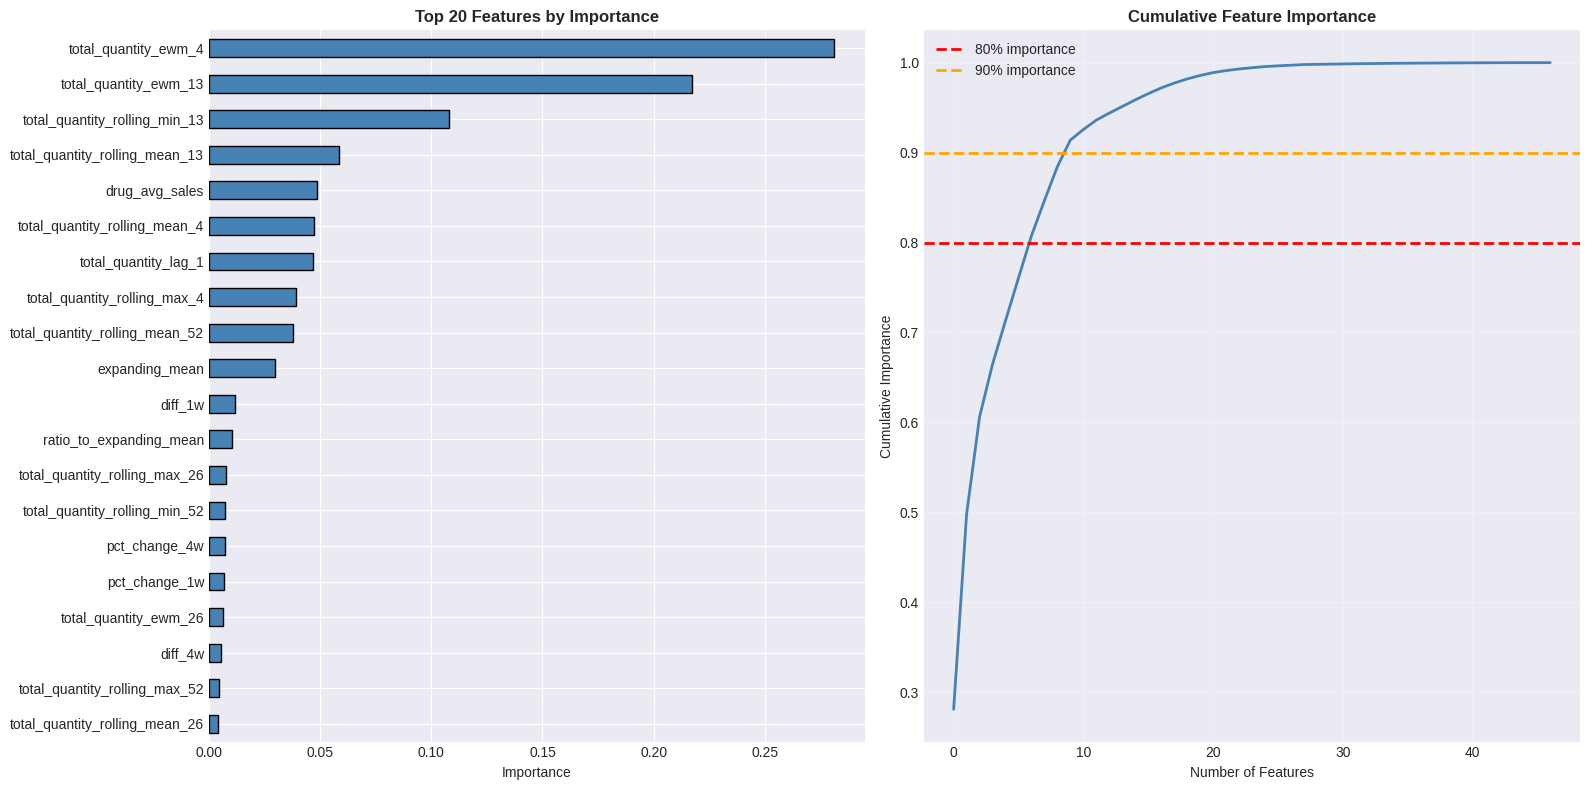


7 features explain 80% of importance
10 features explain 90% of importance
Total features: 47


In [11]:
# Get feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print('=== TOP 20 MOST IMPORTANT FEATURES ===')
display(importance.head(20))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 bar chart
importance.head(20).plot(
    x='feature', y='importance', kind='barh',
    ax=axes[0], legend=False, color='steelblue', edgecolor='black'
)
axes[0].set_title('Top 20 Features by Importance', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Importance')
axes[0].set_ylabel('')
axes[0].invert_yaxis()

# Cumulative importance
importance['cumsum'] = importance['importance'].cumsum()
axes[1].plot(range(len(importance)), importance['cumsum'].values, linewidth=2, color='steelblue')
axes[1].axhline(0.8, color='red', linestyle='--', linewidth=2, label='80% importance')
axes[1].axhline(0.9, color='orange', linestyle='--', linewidth=2, label='90% importance')
axes[1].set_title('Cumulative Feature Importance', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# How many features needed for 80% importance?
n_80 = (importance['cumsum'] <= 0.8).sum() + 1
n_90 = (importance['cumsum'] <= 0.9).sum() + 1
print(f'\n{n_80} features explain 80% of importance')
print(f'{n_90} features explain 90% of importance')
print(f'Total features: {len(feature_cols)}')

## 9. RESIDUAL ANALYSIS

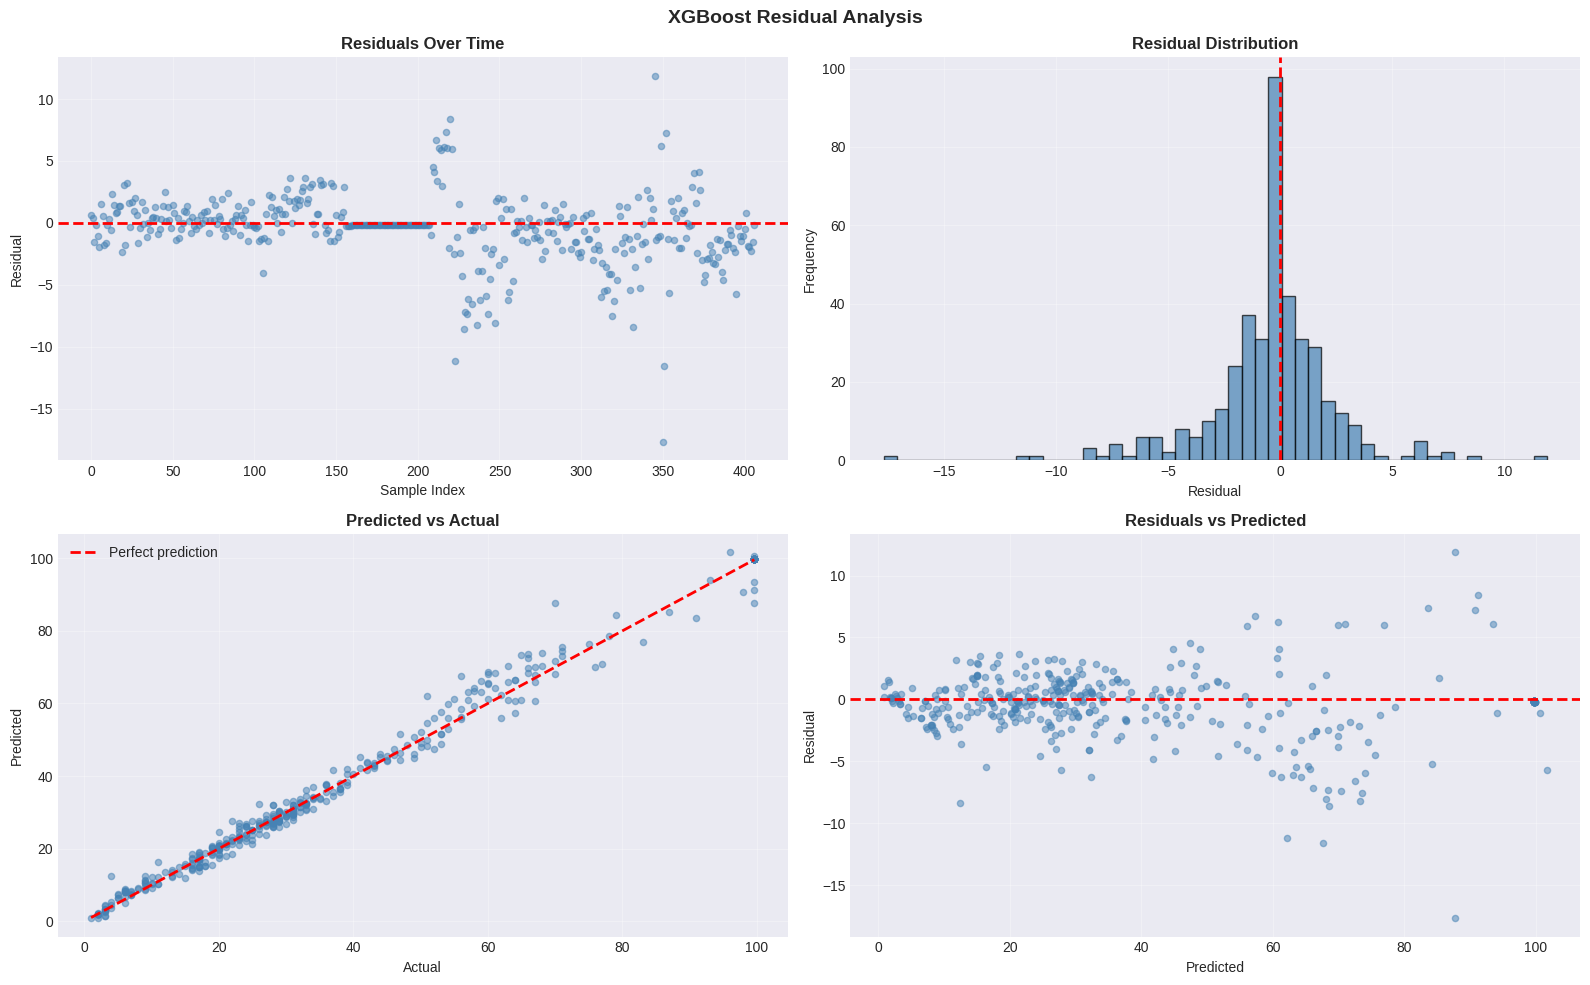

Residual statistics:
  Mean    : -0.44
  Median  : -0.17
  Std Dev : 2.77
  Min     : -17.69
  Max     : 11.90


In [12]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Residuals over time
axes[0,0].scatter(range(len(residuals)), residuals, alpha=0.5, s=20, color='steelblue')
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0,0].set_title('Residuals Over Time', fontweight='bold')
axes[0,0].set_xlabel('Sample Index'); axes[0,0].set_ylabel('Residual')
axes[0,0].grid(True, alpha=0.3)

# Histogram
axes[0,1].hist(residuals, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
axes[0,1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0,1].set_title('Residual Distribution', fontweight='bold')
axes[0,1].set_xlabel('Residual'); axes[0,1].set_ylabel('Frequency')
axes[0,1].grid(True, alpha=0.3)

# Predicted vs Actual
axes[1,0].scatter(y_test, y_pred, alpha=0.5, s=20, color='steelblue')
axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
               'r--', linewidth=2, label='Perfect prediction')
axes[1,0].set_title('Predicted vs Actual', fontweight='bold')
axes[1,0].set_xlabel('Actual'); axes[1,0].set_ylabel('Predicted')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

# Residuals vs Predicted
axes[1,1].scatter(y_pred, residuals, alpha=0.5, s=20, color='steelblue')
axes[1,1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[1,1].set_title('Residuals vs Predicted', fontweight='bold')
axes[1,1].set_xlabel('Predicted'); axes[1,1].set_ylabel('Residual')
axes[1,1].grid(True, alpha=0.3)

plt.suptitle('XGBoost Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print('Residual statistics:')
print(f'  Mean    : {np.mean(residuals):.2f}')
print(f'  Median  : {np.median(residuals):.2f}')
print(f'  Std Dev : {np.std(residuals):.2f}')
print(f'  Min     : {np.min(residuals):.2f}')
print(f'  Max     : {np.max(residuals):.2f}')

## 10. FORECAST VISUALIZATION BY DRUG

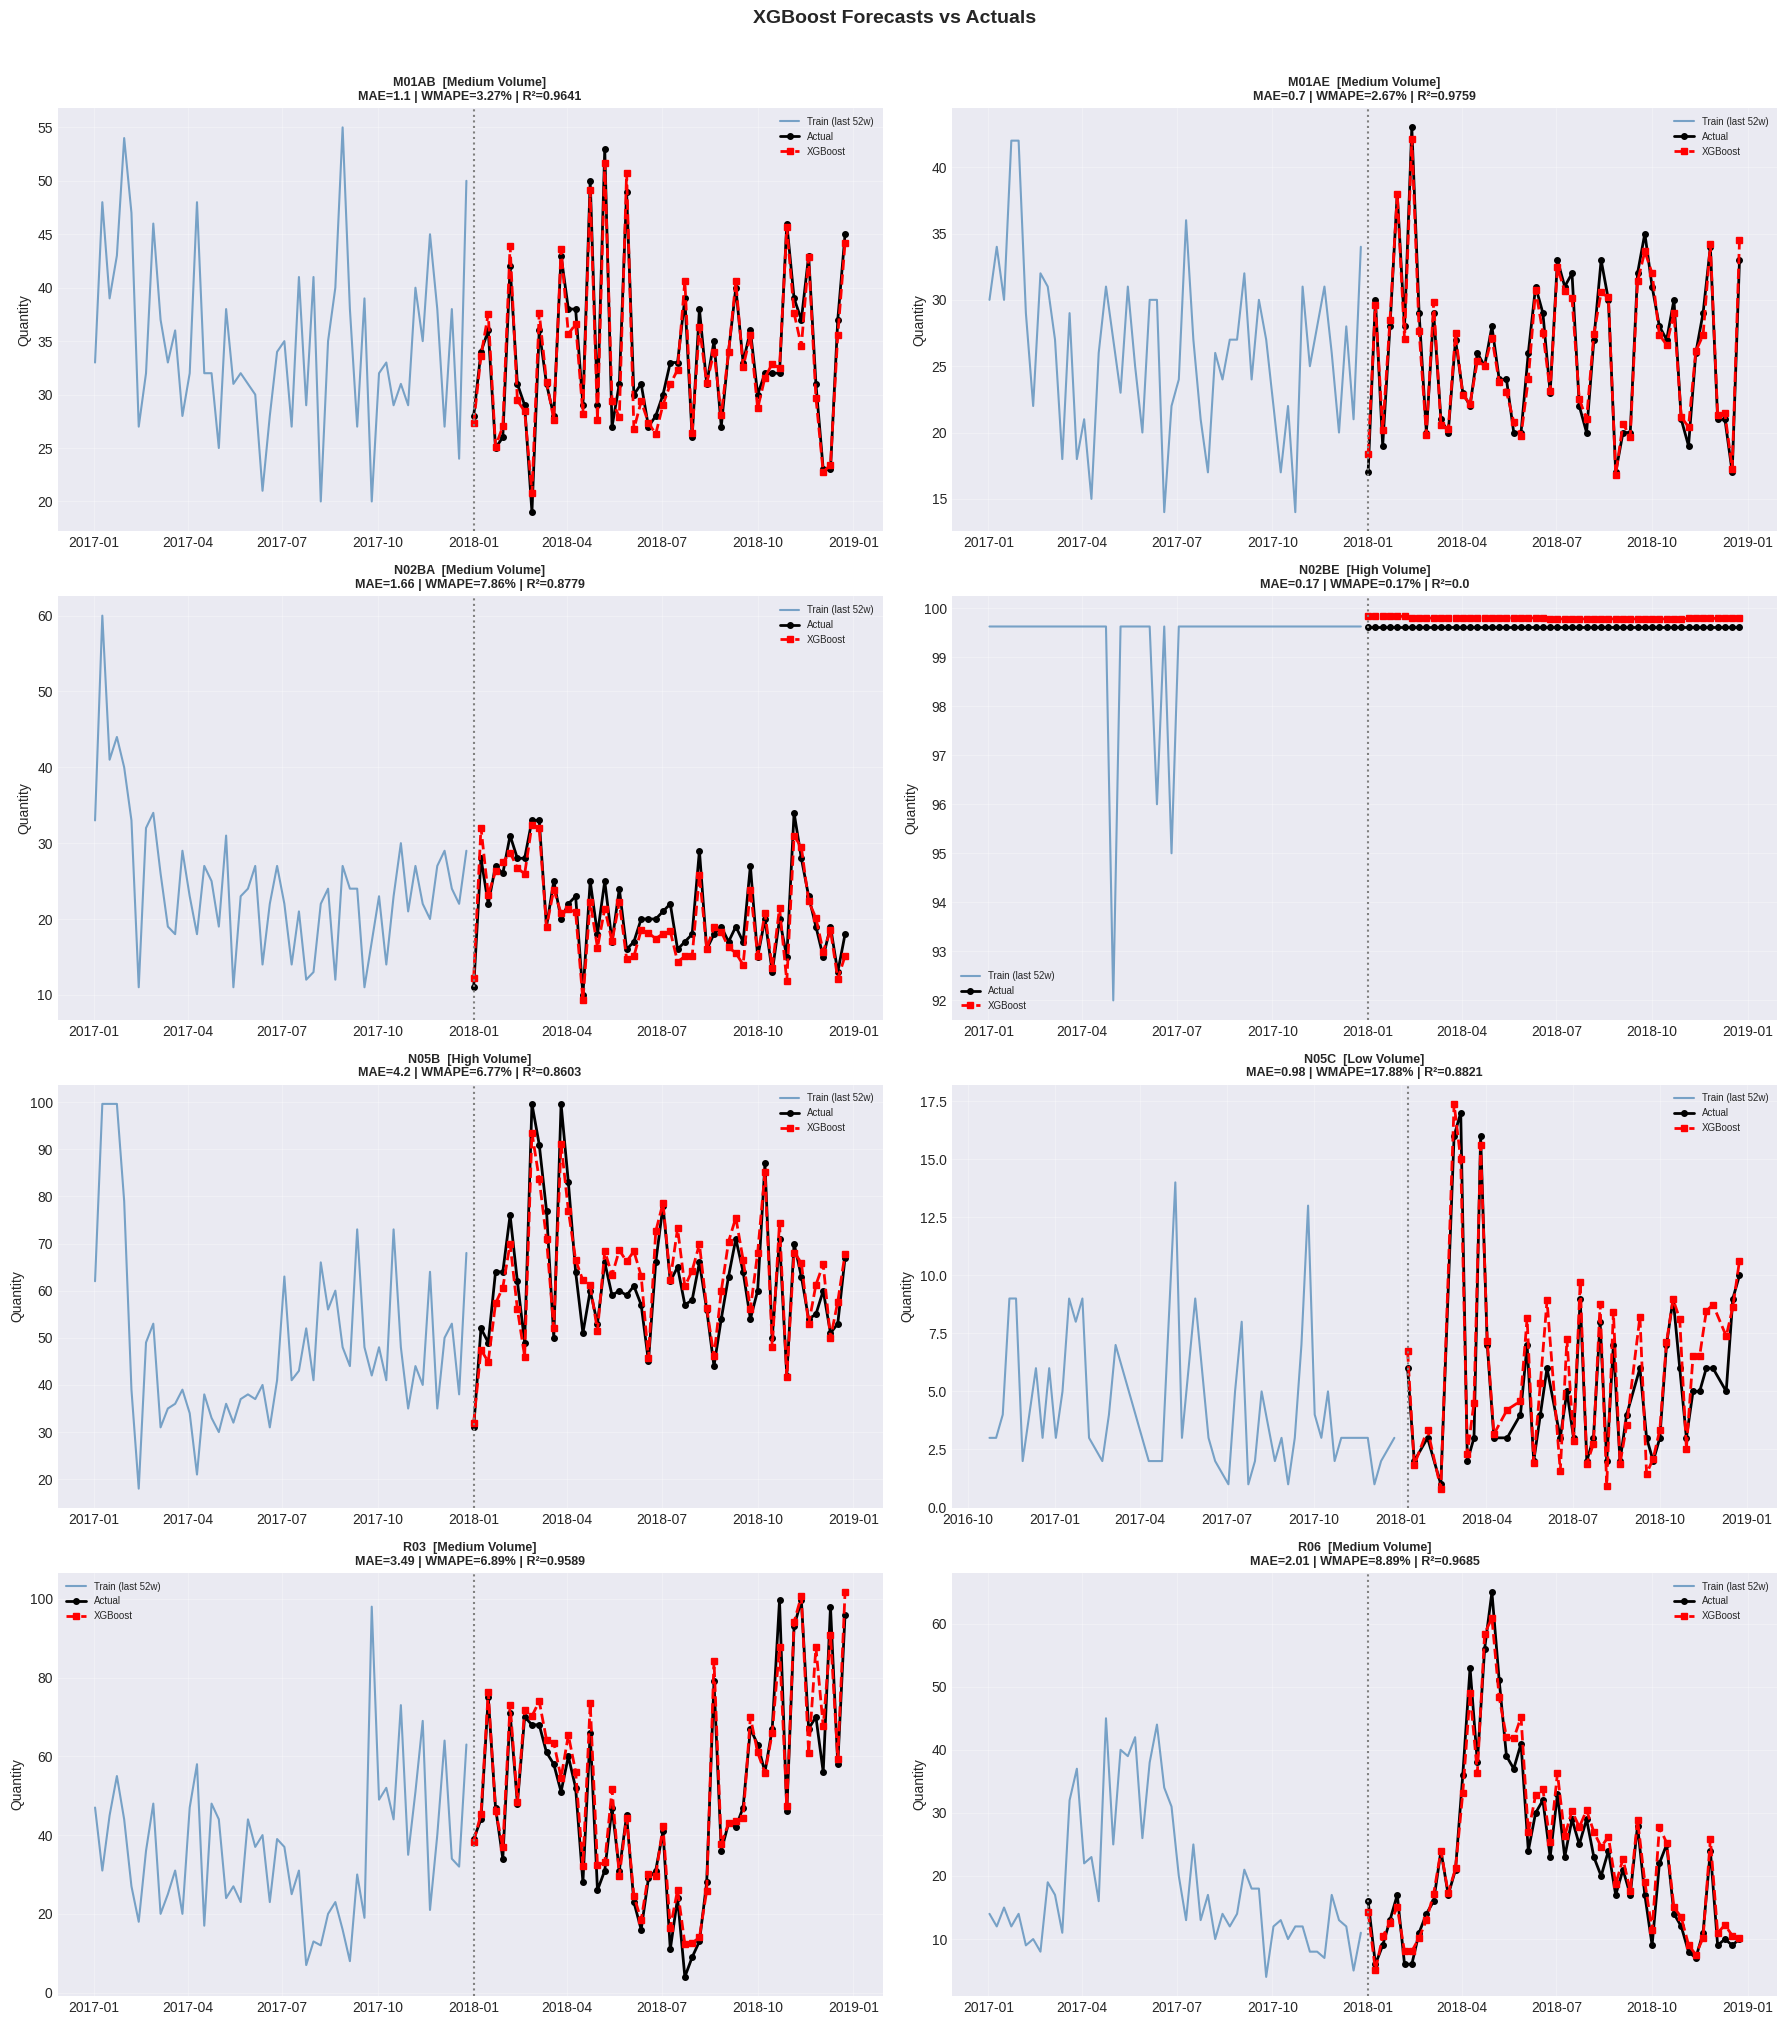

In [13]:
n = len(selected_drugs)
ncols = 2
nrows = max(1, (n + 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for idx, drug in enumerate(selected_drugs):
    ax = axes[idx]
    
    # Get drug data
    train_drug = train_meta[train_meta['drug_name'] == drug]
    test_drug  = test_with_pred[test_with_pred['drug_name'] == drug]
    
    # Plot last 52 weeks of training
    train_plot = train_drug.iloc[-52:]
    if len(train_plot) > 0:
        train_qty = train_df[train_df['drug_name'] == drug].iloc[-52:][TARGET]
        ax.plot(train_plot['week_start_date'], train_qty.values,
                color='steelblue', linewidth=1.5, alpha=0.7, label='Train (last 52w)')
    
    # Plot test actual and predictions
    ax.plot(test_drug['week_start_date'], test_drug['actual'],
            color='black', linewidth=2, marker='o', markersize=4, label='Actual')
    ax.plot(test_drug['week_start_date'], test_drug['xgb_pred'],
            color='red', linewidth=2, linestyle='--', marker='s', markersize=4, label='XGBoost')
    
    # Get metrics for title
    m = results_df[results_df['Drug'] == drug].iloc[0] if len(results_df[results_df['Drug'] == drug]) > 0 else None
    if m is not None:
        title = f"{drug}  [{seg_map.get(drug,'?')}]\nMAE={m['MAE']} | WMAPE={m['WMAPE']}% | R²={m['R2']}"
    else:
        title = drug
    
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axvline(test_drug['week_start_date'].iloc[0], color='gray', linestyle=':', linewidth=1.5)
    ax.set_ylabel('Quantity'); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('XGBoost Forecasts vs Actuals', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 11. PERFORMANCE DASHBOARD

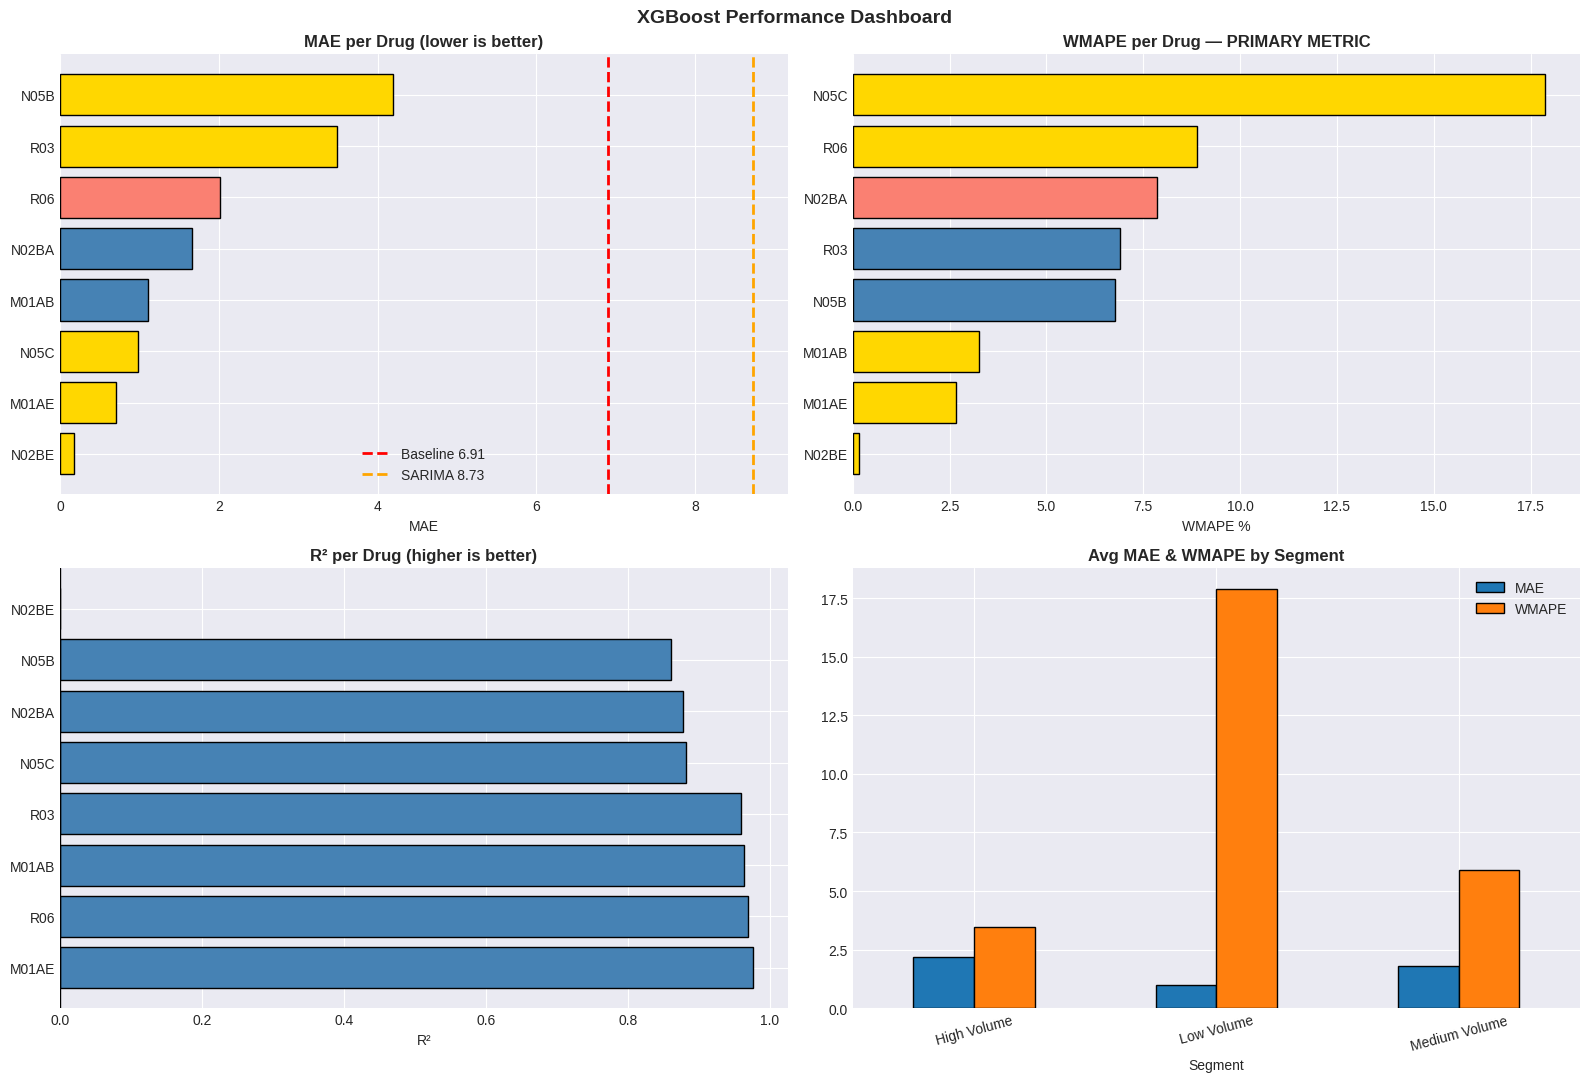

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

colors_s = {'Low Volume':'salmon','Medium Volume':'gold','High Volume':'steelblue','Unknown':'gray'}
bar_clr  = [colors_s.get(results_df.iloc[i]['Segment'],'gray') for i in range(len(results_df))]

# MAE per drug
results_sorted = results_df.sort_values('MAE')
axes[0,0].barh(results_sorted['Drug'], results_sorted['MAE'], color=bar_clr, edgecolor='black')
axes[0,0].axvline(BASELINE_MAE, color='red', linestyle='--', linewidth=2, label=f'Baseline {BASELINE_MAE}')
axes[0,0].axvline(SARIMA_AVG_MAE, color='orange', linestyle='--', linewidth=2, label=f'SARIMA {SARIMA_AVG_MAE}')
axes[0,0].set_title('MAE per Drug (lower is better)', fontweight='bold')
axes[0,0].set_xlabel('MAE'); axes[0,0].legend()

# WMAPE per drug
w_sorted = results_df.sort_values('WMAPE')
axes[0,1].barh(w_sorted['Drug'], w_sorted['WMAPE'], color=bar_clr, edgecolor='black')
axes[0,1].set_title('WMAPE per Drug — PRIMARY METRIC', fontweight='bold')
axes[0,1].set_xlabel('WMAPE %')

# R² per drug
r_sorted = results_df.sort_values('R2', ascending=False)
r_clr    = ['steelblue' if v >= 0 else 'salmon' for v in r_sorted['R2']]
axes[1,0].barh(r_sorted['Drug'], r_sorted['R2'], color=r_clr, edgecolor='black')
axes[1,0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1,0].set_title('R² per Drug (higher is better)', fontweight='bold')
axes[1,0].set_xlabel('R²')

# Segment comparison
seg_avg = results_df.groupby('Segment')[['MAE','WMAPE']].mean()
seg_avg.plot(kind='bar', ax=axes[1,1], edgecolor='black')
axes[1,1].set_title('Avg MAE & WMAPE by Segment', fontweight='bold')
axes[1,1].set_xlabel('Segment'); axes[1,1].tick_params(axis='x', rotation=15)

plt.suptitle('XGBoost Performance Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 12. SAVE RESULTS

In [15]:
import json

out_dir = '../data/results/xgboost'
os.makedirs(out_dir, exist_ok=True)

# Metrics
results_df.to_csv(f'{out_dir}/xgboost_results.csv', index=False)

# Predictions
test_with_pred.to_csv(f'{out_dir}/xgboost_predictions.csv', index=False)

# Feature importance
importance.to_csv(f'{out_dir}/feature_importance.csv', index=False)

# Model (save in both formats)
final_model.save_model(f'{out_dir}/xgboost_model.json')  # XGBoost native format
with open(f'{out_dir}/xgboost_final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)  # Pickle for validation notebook

# Best params
with open(f'{out_dir}/best_params.pkl', 'wb') as f:
    pickle.dump(best_params, f)

# ── Save 2018 validation metrics as JSON ──────────────────────────
# These are loaded by model_validation_2019.ipynb as the baseline benchmark
val_metrics = {
    'mae':          float(overall_metrics['MAE']),
    'mape':         float(overall_metrics['MAPE']) if overall_metrics['MAPE'] is not None else None,
    'r2':           float(overall_metrics['R2']),
    'wmape':        float(overall_metrics['WMAPE']) if overall_metrics['WMAPE'] is not None else None,
    'train_period': '2014-2017',
    'val_period':   '2018'
}
with open(f'{out_dir}/validation_2018_metrics.json', 'w') as f:
    json.dump(val_metrics, f, indent=2)

print('✓ Saved to', out_dir)
for fname in ['xgboost_results.csv', 'xgboost_predictions.csv',
              'feature_importance.csv', 'xgboost_model.json',
              'xgboost_final_model.pkl', 'best_params.pkl',
              'validation_2018_metrics.json']:
    print(f'   {fname}')


✓ Saved to ../data/results/xgboost
   xgboost_results.csv
   xgboost_predictions.csv
   feature_importance.csv
   xgboost_model.json
   xgboost_final_model.pkl
   best_params.pkl
   validation_2018_metrics.json


## 13. FINAL MODEL COMPARISON

In [16]:
print('=' * 70)
print('FINAL MODEL COMPARISON — ALL THREE APPROACHES')
print('=' * 70)

all_models = pd.DataFrame({
    'Holt-Winters': [BASELINE_MAE,   '—',         28.36,  -0.39,   'baseline'],
    'SARIMA (avg)': [SARIMA_AVG_MAE, '—',         31.89,  -1.03,   'statistical'],
    'XGBoost'     : [overall_metrics['MAE'], 
                     overall_metrics['WMAPE'],
                     overall_metrics['MAPE'],
                     overall_metrics['R2'],
                     'ML']
}, index=['MAE','WMAPE (primary)','MAPE','R2','Type'])

display(all_models)

# Ranking
mae_values = {
    'Holt-Winters': BASELINE_MAE,
    'SARIMA': SARIMA_AVG_MAE,
    'XGBoost': overall_metrics['MAE']
}
ranking = sorted(mae_values.items(), key=lambda x: x[1])

print('\n📊 RANKING BY MAE:')
for i, (model, mae) in enumerate(ranking, 1):
    print(f'  {i}. {model:15s}  MAE = {mae:.2f}')

print('\n🏆 WINNER:', ranking[0][0])

# Per-drug winners
print('\n💡 PER-DRUG ANALYSIS:')
print('SARIMA better for:')
for drug in comp[comp['XGB_beats_SARIMA'] == False]['Drug'].tolist():
    s_mae = comp[comp['Drug']==drug]['SARIMA_MAE'].values[0]
    x_mae = comp[comp['Drug']==drug]['MAE'].values[0]
    print(f'  {drug:10s}  SARIMA={s_mae:.2f}  XGB={x_mae:.2f}')

print('\nXGBoost better for:')
for drug in comp[comp['XGB_beats_SARIMA'] == True]['Drug'].tolist():
    s_mae = comp[comp['Drug']==drug]['SARIMA_MAE'].values[0]
    x_mae = comp[comp['Drug']==drug]['MAE'].values[0]
    print(f'  {drug:10s}  SARIMA={s_mae:.2f}  XGB={x_mae:.2f}')

print('\n📌 RECOMMENDATION:')
if overall_metrics['MAE'] < BASELINE_MAE and overall_metrics['MAE'] < SARIMA_AVG_MAE:
    print('  Use XGBoost as primary forecasting model.')
    print('  It beats both baselines and handles all drugs in one model.')
elif overall_metrics['MAE'] < SARIMA_AVG_MAE:
    print('  XGBoost beats SARIMA but not Holt-Winters.')
    print('  Consider ensemble: XGBoost + Holt-Winters weighted by drug segment.')
else:
    print('  XGBoost did not beat baselines.')
    print('  Recommended: Per-drug hybrid approach')
    print('    - Use SARIMA for high-volume stable drugs')
    print('    - Use XGBoost for volatile / low-volume drugs')
    print('    - Use Holt-Winters as fallback')

print('\n' + '=' * 70)

FINAL MODEL COMPARISON — ALL THREE APPROACHES


,Holt-Winters,SARIMA (avg),XGBoost
MAE,6.9100,8.7300,1.8100
WMAPE (primary),—,—,4.4100
MAPE,28.3600,31.8900,6.2300
R2,-0.3900,-1.0300,0.9913
Type,baseline,statistical,ML



📊 RANKING BY MAE:
  1. XGBoost          MAE = 1.81
  2. Holt-Winters     MAE = 6.91
  3. SARIMA           MAE = 8.73

🏆 WINNER: XGBoost

💡 PER-DRUG ANALYSIS:
SARIMA better for:
  N02BE       SARIMA=0.00  XGB=0.17

XGBoost better for:
  M01AB       SARIMA=6.36  XGB=1.10
  M01AE       SARIMA=6.43  XGB=0.70
  N02BA       SARIMA=6.28  XGB=1.66
  N05B        SARIMA=13.16  XGB=4.20
  N05C        SARIMA=4.05  XGB=0.98
  R03         SARIMA=26.09  XGB=3.49
  R06         SARIMA=7.24  XGB=2.01

📌 RECOMMENDATION:
  Use XGBoost as primary forecasting model.
  It beats both baselines and handles all drugs in one model.

